In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("Network Traffic.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,True,True,False,False,False,False,False,False
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,True,False,False,False,True,False,True,False
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,True,False,False,True,False,False,False,False
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,False,False,True,False,False,False,False,False
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,False,False,True,False,False,False,True,False


In [6]:
print("Shape of Dataset :", df.shape)


Shape of Dataset : (1000, 18)


In [7]:
print("\nColumn Names:\n")
print(df.columns)


Column Names:

Index(['packet_size', 'inter_arrival_time', 'src_port', 'dst_port',
       'packet_count_5s', 'mean_packet_size', 'spectral_entropy',
       'frequency_band_energy', 'label', 'protocol_type_TCP',
       'protocol_type_UDP', 'src_ip_192.168.1.2', 'src_ip_192.168.1.3',
       'dst_ip_192.168.1.5', 'dst_ip_192.168.1.6', 'tcp_flags_FIN',
       'tcp_flags_SYN', 'tcp_flags_SYN-ACK'],
      dtype='object')


In [8]:
print("\nDataset Info:\n")
df.info()


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   packet_size            1000 non-null   float64
 1   inter_arrival_time     1000 non-null   float64
 2   src_port               1000 non-null   int64  
 3   dst_port               1000 non-null   int64  
 4   packet_count_5s        1000 non-null   float64
 5   mean_packet_size       1000 non-null   float64
 6   spectral_entropy       1000 non-null   float64
 7   frequency_band_energy  1000 non-null   float64
 8   label                  1000 non-null   float64
 9   protocol_type_TCP      1000 non-null   bool   
 10  protocol_type_UDP      1000 non-null   bool   
 11  src_ip_192.168.1.2     1000 non-null   bool   
 12  src_ip_192.168.1.3     1000 non-null   bool   
 13  dst_ip_192.168.1.5     1000 non-null   bool   
 14  dst_ip_192.168.1.6     1000 non-null   bo

In [9]:
missing_values = df.isnull().sum()

print(missing_values)

packet_size              0
inter_arrival_time       0
src_port                 0
dst_port                 0
packet_count_5s          0
mean_packet_size         0
spectral_entropy         0
frequency_band_energy    0
label                    0
protocol_type_TCP        0
protocol_type_UDP        0
src_ip_192.168.1.2       0
src_ip_192.168.1.3       0
dst_ip_192.168.1.5       0
dst_ip_192.168.1.6       0
tcp_flags_FIN            0
tcp_flags_SYN            0
tcp_flags_SYN-ACK        0
dtype: int64


In [10]:
df = df.dropna()

print("Missing Values Removed")
print("New Shape :", df.shape)

Missing Values Removed
New Shape : (1000, 18)


In [11]:
X = df.select_dtypes(include=['int64', 'float64'])

print("Selected Numeric Features")
X.head()

Selected Numeric Features


,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0


In [12]:
X.describe()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000.000000,1000.000000,1000.00000
mean,0.502446,0.512259,32024.617000,199.769000,0.506857,0.0,0.495222,0.485651,0.10000
std,0.289606,0.281130,18520.890349,180.078488,0.303271,0.0,0.292927,0.295953,0.30015
min,0.000000,0.000000,1038.000000,53.000000,0.000000,0.0,0.000000,0.000000,0.00000
25%,0.256263,0.275909,16245.250000,53.000000,0.267857,0.0,0.236912,0.228039,0.00000
50%,0.499642,0.515971,31883.000000,80.000000,0.500000,0.0,0.504290,0.467905,0.00000
75%,0.741410,0.746523,47746.250000,443.000000,0.785714,0.0,0.761556,0.750876,0.00000
max,1.000000,1.000000,65484.000000,443.000000,1.000000,0.0,1.000000,1.000000,1.00000


In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


In [14]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

model.fit(X_scaled)

print("Model Training Completed")

Model Training Completed


In [15]:
predictions = model.predict(X_scaled)

predictions[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [16]:
df['Anomaly'] = predictions

df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK,Anomaly
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,True,True,False,False,False,False,False,False,1
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,True,False,False,False,True,False,True,False,1
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,True,False,False,True,False,False,False,False,1
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,False,False,True,False,False,False,False,False,1
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,False,False,True,False,False,False,True,False,1


In [17]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA Transformation Completed")

PCA Transformation Completed


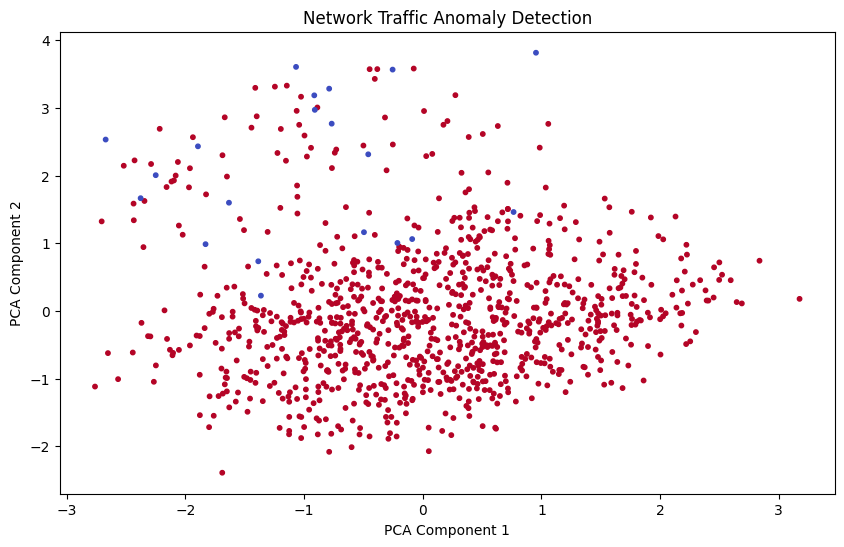

In [18]:
plt.figure(figsize=(10,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['Anomaly'],
    cmap='coolwarm',
    s=10
)

plt.title("Network Traffic Anomaly Detection")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

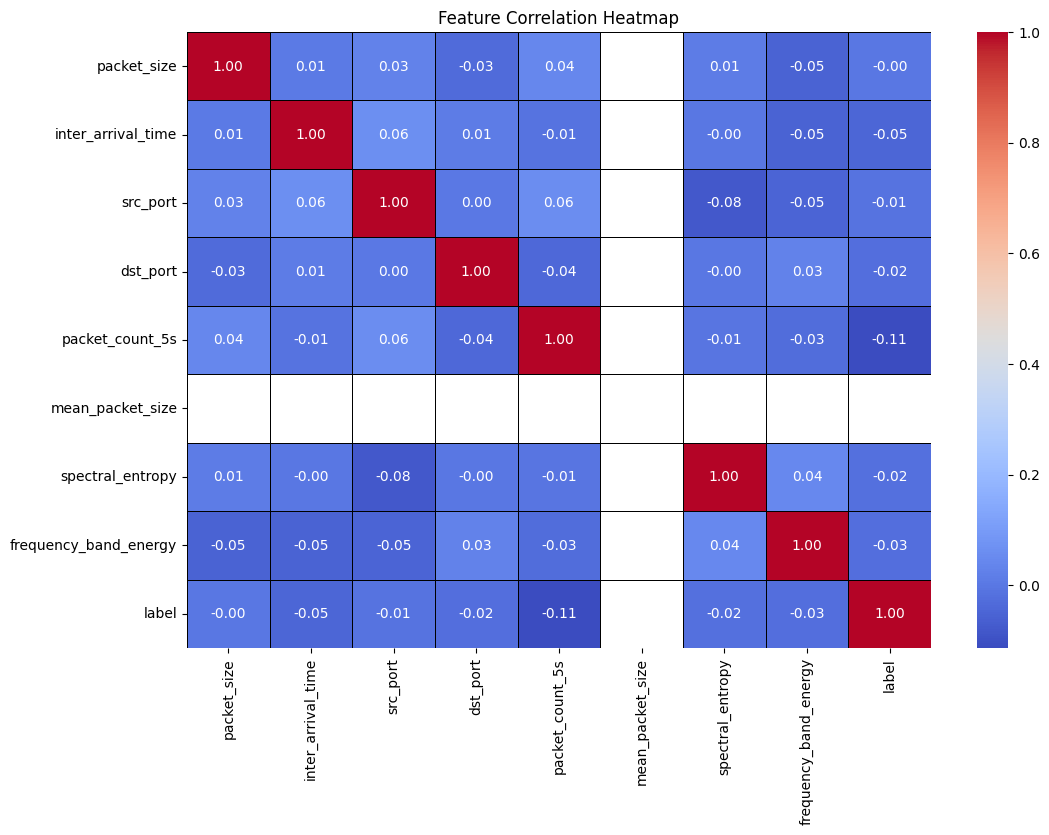

In [20]:
plt.figure(figsize=(12,8))
sns.heatmap(
    X.corr(),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='black'
)

plt.title("Feature Correlation Heatmap")
plt.show()

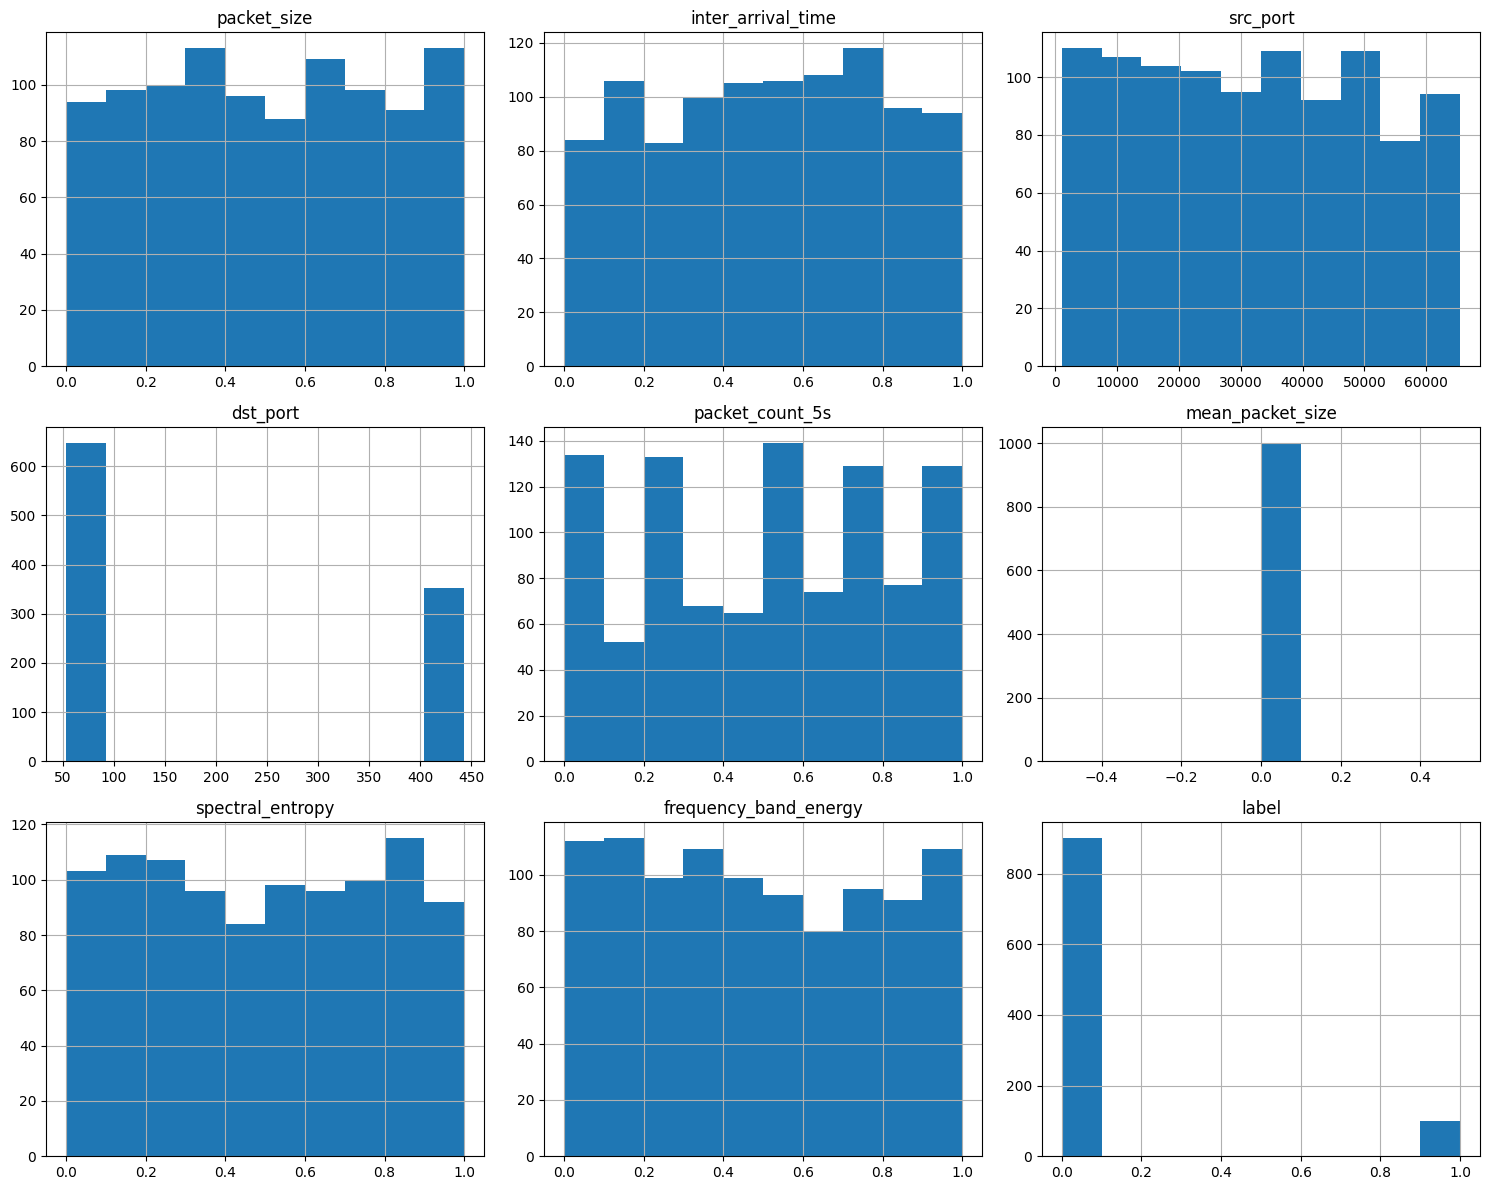

In [22]:
X.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

In [24]:
normal = (df['Anomaly'] == 1).sum()
anomaly = (df['Anomaly'] == -1).sum()
total = len(df)

print(f"Normal Traffic  : {normal}")
print(f"Anomalies       : {anomaly}")
print(f"\nAnomaly Percentage : {(anomaly/total)*100:.2f}%")

Normal Traffic  : 980
Anomalies       : 20

Anomaly Percentage : 2.00%


* Built an unsupervised machine learning project for anomaly detection
* Used the Isolation Forest algorithm to identify unusual network traffic
* Performed data cleaning and preprocessing
* Applied feature scaling using StandardScaler
* Used PCA for dimensionality reduction and visualization
* Visualized normal and anomalous traffic patterns
* Detected suspicious or abnormal network behavior automatically
* Generated a final dataset with anomaly predictions
* Learned concepts of anomaly detection and cybersecurity analytics
* Demonstrated a real-world application of machine learning in network monitoring
